# Common Libraries

In [1]:
import os, sys, shutil, mediapy, itertools
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module/")

from sj_datastructure import make_3d_dataset
from sj_visualization import plot_3D_dataset, plot_3D_datasets
from sj_array import reorient_array
from biomechanics_util import get_joint_pos, get_body_pos, get_site_pos, transform_ds, find_child_bodies, get_geom_pos
from biomechanics_util import extract_geometry_info, calc_joint_angle, get_joint_segments, calc_geom_angle

In [3]:
def get_MoBL_finger_info(geometry_df, fingers = ["Index", "Middle", "Ring", "Little", "Thumb"]):
    """
    Get finger information from geometry data

    :param fingers: searching finger names

    return (dictionary)
    """
    finger_info = {}
    for finger in fingers:
        if finger == "Index":
            finger_number = 2
            number_str = "Second"
        elif finger == "Middle":
            finger_number = 3
            number_str = "Third"
        elif finger == "Ring":
            finger_number = 4
            number_str = "Fourth"
        elif finger == "Little":
            finger_number = 5
            number_str = "Fifth"
        
        if finger in ["Index", "Middle", "Ring", "Little"]:
            mcp = geometry_df[geometry_df["geom_name"].str.contains(f"_{finger_number}rdmcp_ext|{number_str}mcp_ext", na = False)]["geom_name"].iloc[0]
            pm = geometry_df[geometry_df["geom_name"].str.contains(f"_{finger_number}rdpm_ext|{number_str}pm_ext", na = False)]["geom_name"].iloc[0]
            md = geometry_df[geometry_df["geom_name"].str.contains(f"_{finger_number}rdmd_ext|{number_str}md_ext", na = False)]["geom_name"].iloc[0]
            ft = geometry_df[geometry_df["mesh_file_path"].str.contains(f"hand_{finger_number}distph", na = False)]["geom_name"].iloc[0]

            finger_info[finger] = [mcp, pm, md, ft]
        else:
            mc = geometry_df[geometry_df["geom_name"].str.contains(f"hand_geom_23", na = False)]["geom_name"].iloc[0]
            mp = geometry_df[geometry_df["geom_name"].str.contains(f"MPthumb", na = False)]["geom_name"].iloc[0]
            ip = geometry_df[geometry_df["geom_name"].str.contains(f"IPthumb", na = False)]["geom_name"].iloc[0]
            tt = geometry_df[geometry_df["mesh_file_path"].str.contains(f"hand_thumbdist", na = False)]["geom_name"].iloc[0]
            
            finger_info[finger] = [mc, mp, ip, tt]
    return finger_info

def get_myoarm_fingerJoint_info(joint_df, fingers = ["Index", "Middle", "Ring", "Little", "Thumb"]):
    """
    Get finger information from geometry data

    :param fingers: searching finger names

    return (dictionary)
    """
    finger_info = {}
    for finger in fingers:
        if finger == "Index":
            finger_number = 2
        elif finger == "Middle":
            finger_number = 3
        elif finger == "Ring":
            finger_number = 4
        elif finger == "Little":
            finger_number = 5
        
        if finger in ["Index", "Middle", "Ring", "Little"]:
            mcp = joint_df[joint_df["joint_name"].str.contains(f"mcp{finger_number}_flexion", na = False)]["joint_name"].iloc[0]
            pm = joint_df[joint_df["joint_name"].str.contains(f"pm{finger_number}_flexion", na = False)]["joint_name"].iloc[0]
            md = joint_df[joint_df["joint_name"].str.contains(f"md{finger_number}_flexion", na = False)]["joint_name"].iloc[0]
            finger_info[finger] = [mcp, pm, md]
        else:
            mc = joint_df[joint_df["joint_name"].str.contains("cmc_flexion")]["joint_name"].iloc[0]
            mp = joint_df[joint_df["joint_name"].str.contains("mp_flexion")]["joint_name"].iloc[0]
            ip = joint_df[joint_df["joint_name"].str.contains("ip_flexion")]["joint_name"].iloc[0]
            finger_info[finger] = [mc, mp, ip]
    return finger_info

In [4]:
def get_mobl_finger_infos(geometry_df):
    finger_info = get_MoBL_finger_info(geometry_df)

    for finger in finger_info:
        additional_body = ""
        if finger == "Index":
            additional_body = "hand_geom_6"
        elif finger == "Middle":
            additional_body = "hand_geom_8"
        elif finger == "Ring":
            additional_body = "hand_geom_7"
        elif finger == "Little":
            additional_body = "hand_geom_7"
        elif finger == "Thumb":
            additional_body = "hand_geom_6"
            
        # finger_info[finger] = [additional_body] + finger_info[finger]
        finger_info[finger] = finger_info[finger]
        
    return finger_info

def get_myoarm_hand_info(model, joint_df):
    joint_info = get_myoarm_fingerJoint_info(joint_df)

    segment_info = {
        finger: {
            joint: dict(zip(
                ["parent", "child"],
                get_joint_segments(model=model, joint_name=joint)
            ))
            for joint in joints
        }
        for finger, joints in joint_info.items()
    }

    additional_bodies = {
        "Index": "trapezoid",
        "Middle": "capitate",
        "Ring": "hamate",
        "Little": "hamate",
        "Thumb": "trapezoid",
    }

    body_names_by_finger = {}

    for finger, joints in segment_info.items():
        bodies = [additional_bodies[finger]]
        bodies += [
            body
            for seg in joints.values()
            for body in seg.values()
        ]

        body_names_by_finger[finger] = list(dict.fromkeys(bodies))

    return joint_info, body_names_by_finger

In [5]:
biomechanics_default_pos = {
        # Global coords
        "r_x" : np.deg2rad(0),
        "r_y" : np.deg2rad(0),
        "r_z" : np.deg2rad(0),
        "t_x" : np.deg2rad(0),
        "t_y" : np.deg2rad(0),
        "t_z" : np.deg2rad(0),

        # Shoulder
        "elv_angle" : np.deg2rad(77.462),
        "shoulder_elv" : np.deg2rad(42.944),
        "shoulder_rot" : np.deg2rad(95.482),

        # Elbow
        "elbow_flexion" : np.deg2rad(28.376),

        # Wrist
        "pro_sup" : np.deg2rad(-36.562),
        "deviation" : np.deg2rad(0.080),
        "flexion" : np.deg2rad(-0.142),

        # Thumb
        "cmc_abduction" : np.deg2rad(-14.3239),
        "cmc_flexion" : np.deg2rad(18.9076),
        "mp_flexion" : np.deg2rad(-44.9771),
        "ip_flexion" : np.deg2rad(24.98096),

        # Index finger
        "mcp2_flexion" : np.deg2rad(49.2743),
        "mcp2_abduction" : np.deg2rad(0),
        "pm2_flexion" : np.deg2rad(80.7870),
        "md2_flexion" : np.deg2rad(0),

        # Middle finger
        "mcp3_flexion" : np.deg2rad(49.2743),
        "mcp3_abduction" : np.deg2rad(0),
        "pm3_flexion" : np.deg2rad(80.7870),
        "md3_flexion" : np.deg2rad(0),
        
        # Ring finger
        "mcp4_flexion" : np.deg2rad(49.2743),
        "mcp4_abduction" : np.deg2rad(0),
        "pm4_flexion" : np.deg2rad(80.7870),
        "md4_flexion" : np.deg2rad(0),
        
        # Little finger
        "mcp5_flexion" : np.deg2rad(49.2743),
        "mcp5_abduction" : np.deg2rad(0),
        "pm5_flexion" : np.deg2rad(80.7870),
        "md5_flexion" : np.deg2rad(0),
    }

# Params

In [6]:
convertedModel_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_41/temp_cvt3.xml"
myoarm_path = "/mnt/ext1/seojin/temp/myoarm_full.xml"

convertedModel_coords = "PRI"
myoarm_coords = "RAI"

ref_body = "thorax" # "thorax"

# Constants

In [7]:
ref_coords = myoarm_coords

# Model

In [8]:
convertedModel = mujoco.MjModel.from_xml_path(convertedModel_path)
convertedModel_data = mujoco.MjData(convertedModel)
convertedModel_joint_names = [mujoco.mj_id2name(convertedModel, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(convertedModel.njnt)]

myoarmModel = mujoco.MjModel.from_xml_path(myoarm_path)
myoarmModel_data = mujoco.MjData(myoarmModel)
myoarmModel_joint_names = [mujoco.mj_id2name(myoarmModel, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(myoarmModel.njnt)]

In [9]:
adjusted_convertedModel_qpos = np.zeros_like(convertedModel_data.qpos)
for joint_name in biomechanics_default_pos:
    if joint_name in convertedModel_joint_names:
        i = convertedModel_joint_names.index(joint_name)
        adjusted_convertedModel_qpos[i] = biomechanics_default_pos[joint_name]
convertedModel_data.qpos[:] = adjusted_convertedModel_qpos
mujoco.mj_forward(convertedModel, convertedModel_data)

adjusted_myoarm_qpos = np.zeros_like(myoarmModel_data.qpos)
for joint_name in biomechanics_default_pos:
    if joint_name in myoarmModel_joint_names:
        i = myoarmModel_joint_names.index(joint_name)
        adjusted_myoarm_qpos[i] = biomechanics_default_pos[joint_name]
myoarmModel_data.qpos[:] = adjusted_myoarm_qpos
mujoco.mj_forward(myoarmModel, myoarmModel_data)

# Render

In [10]:
# Render
mobl_renderer = mujoco.Renderer(convertedModel, height=400, width=600)
myoarm_renderer = mujoco.Renderer(myoarmModel, height=400, width=600)

# Scene option
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
myoarm_camera = mujoco.MjvCamera()
myoarm_camera.azimuth = 90
myoarm_camera.elevation = 0
myoarm_camera.distance = 3.0

mobl_camera = mujoco.MjvCamera()
mobl_camera.azimuth = 180
mobl_camera.elevation = 0
mobl_camera.distance = 2.0

# Load data

In [11]:
# ConvertedModel - df
convertedModel_joint_df = get_joint_pos(convertedModel, convertedModel_data)
convertedModel_body_df = get_body_pos(convertedModel, convertedModel_data)
convertedModel_site_df = get_site_pos(convertedModel, convertedModel_data)
convertedModel_geometry_df = get_geom_pos(convertedModel_path, convertedModel, convertedModel_data)

# ConvertedModel - ds
convertedModel_joint_ds = transform_ds(convertedModel_joint_df, name_col = "joint_name")
convertedModel_joint_ds["3D"].data = reorient_array(convertedModel_joint_ds["3D"].to_numpy(), convertedModel_coords, ref_coords)

convertedModel_body_ds = transform_ds(convertedModel_body_df, name_col = "body_name")
convertedModel_body_ds["3D"].data = reorient_array(convertedModel_body_ds["3D"].to_numpy(), convertedModel_coords, ref_coords)

convertedModel_site_ds = transform_ds(convertedModel_site_df, name_col = "site_name")
convertedModel_site_ds["3D"].data = reorient_array(convertedModel_site_ds["3D"].to_numpy(), convertedModel_coords, ref_coords)

convertedModel_geometry_ds = transform_ds(convertedModel_geometry_df, name_col = "geom_name")
convertedModel_geometry_ds["3D"].data = reorient_array(convertedModel_geometry_ds["3D"].to_numpy(), convertedModel_coords, ref_coords)

# MyoArm - df
myoarm_joint_df = get_joint_pos(myoarmModel, myoarmModel_data)
myoarm_body_df = get_body_pos(myoarmModel, myoarmModel_data)
myoarm_site_df = get_site_pos(myoarmModel, myoarmModel_data)
myoarm_geometry_df = get_geom_pos(myoarm_path, myoarmModel, myoarmModel_data)
myoarm_geometry_df = myoarm_geometry_df[np.logical_not(pd.isna(myoarm_geometry_df["geom_name"]))]
myoarm_geometry_df = myoarm_geometry_df[myoarm_geometry_df["parent_body_name"] != "world"]

# MyoArm - ds
myoarm_joint_ds = transform_ds(myoarm_joint_df, name_col = "joint_name")
myoarm_body_ds = transform_ds(myoarm_body_df, name_col = "body_name")
myoarm_site_ds = transform_ds(myoarm_site_df, name_col = "site_name")
myoarm_geometry_ds = transform_ds(myoarm_geometry_df, name_col = "geom_name")

# Align coordinate with origin correction

In [12]:
# Ref
convertedModel_ref = convertedModel_body_ds.sel(Times = 0, Labels = ref_body)["3D"].to_numpy()
myoarm_ref = myoarm_body_ds.sel(Times = 0, Labels = ref_body)["3D"].to_numpy()

# Offset
offset = myoarm_ref - convertedModel_ref

# Origin correction
convertedModel_joint_ds["3D"].data = convertedModel_joint_ds["3D"].data + offset
convertedModel_body_ds["3D"].data = convertedModel_body_ds["3D"].data + offset
convertedModel_site_ds["3D"].data = convertedModel_site_ds["3D"].data + offset
convertedModel_geometry_ds["3D"].data = convertedModel_geometry_ds["3D"].data + offset

# Whoel body

In [13]:
plot_3D_datasets([convertedModel_body_ds, myoarm_body_ds], ref_coords)

# Hand

In [14]:
# ConvertedModel
convertedModel_finger_info = get_mobl_finger_infos(convertedModel_geometry_df)
convertedModel_finger_geom_names = [convertedModel_finger_info[finger] for finger in convertedModel_finger_info]
convertedModel_hand_skeletons = [list(zip(geom_names[:-1], geom_names[1:])) for geom_names in convertedModel_finger_geom_names]
convertedModel_hand_skeletons = list(itertools.chain(*convertedModel_hand_skeletons))
convertedModel_finger_geom_names = np.unique(list(itertools.chain(*convertedModel_finger_geom_names)))

# MyoArm
myoarm_jointFinger_info, myoarm_body_names_by_finger = get_myoarm_hand_info(myoarmModel, myoarm_joint_df)
myoarm_finger_body_names = np.unique(np.array([myoarm_body_names_by_finger[finger] for finger in myoarm_body_names_by_finger]).flatten())
myoarm_hand_skeletons = [pair for bodies in myoarm_body_names_by_finger.values() for pair in zip(bodies[:-1], bodies[1:])]

# Plot hand pose
plot_3D_datasets([convertedModel_geometry_ds.sel(Labels = convertedModel_finger_geom_names), 
                  myoarm_body_ds.sel(Labels = myoarm_finger_body_names)], ref_coords,
                 skeletons_list = [convertedModel_hand_skeletons, myoarm_hand_skeletons])

# Render

In [24]:
convertedModel_ref_body_pos = myoarm_body_ds.sel(Times = convertedModel_body_ds.Times[0], Labels = ref_body)["3D"].to_numpy()
myoarm_ref_body_pos = myoarm_body_ds.sel(Times = myoarm_body_ds.Times[0], Labels = ref_body)["3D"].to_numpy()

In [27]:
# Render
mobl_renderer = mujoco.Renderer(convertedModel, height=400, width=600)
myoarm_renderer = mujoco.Renderer(myoarmModel, height=400, width=600)

# Scene option
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# myoarm camera
myoarm_camera = mujoco.MjvCamera()
myoarm_camera.azimuth = 90
myoarm_camera.elevation = 0
myoarm_camera.distance = 3.0
myoarm_camera.lookat = myoarm_ref_body_pos

# convertedModel camera
convertedModel_camera = mujoco.MjvCamera()
convertedModel_camera.azimuth = 180
convertedModel_camera.elevation = 0
convertedModel_camera.distance = 2.0
convertedModel_camera.lookat = convertedModel_ref_body_pos

# Images

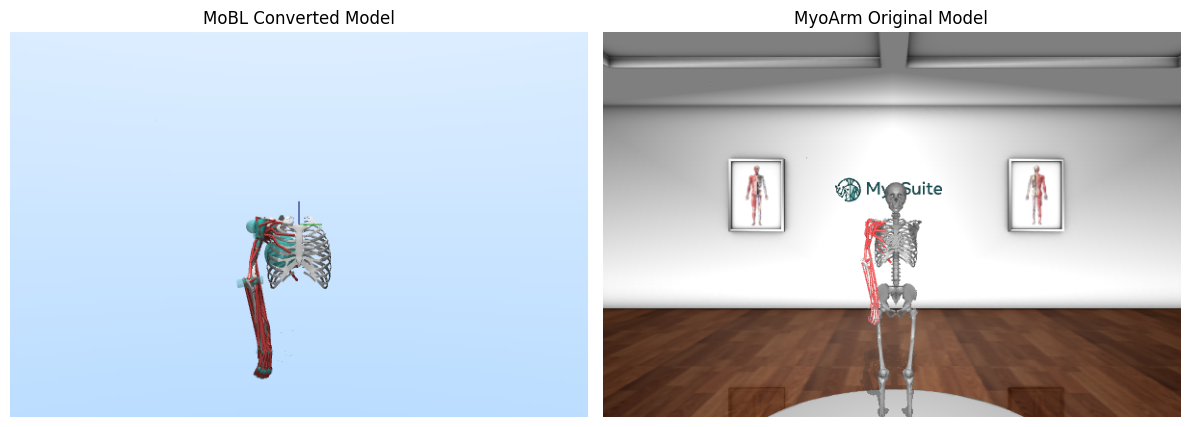

In [28]:
mobl_renderer.update_scene(convertedModel_data, scene_option = scene_option, camera = mobl_camera)
myoarm_renderer.update_scene(myoarmModel_data, scene_option = scene_option, camera = myoarm_camera)

img1 = mobl_renderer.render()
img2 = myoarm_renderer.render()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].set_title("MoBL Converted Model")
axes[0].axis('off') # 격자 눈금 가리기

axes[1].imshow(img2)
axes[1].set_title("MyoArm Original Model")
axes[1].axis('off')

plt.tight_layout()
plt.show()